In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


In [2]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [3]:
# By default n_estimators=100, max_depth=3, learning_rate=0.1
gbc = GradientBoostingClassifier(random_state=0)
gbc.fit(X_train, y_train)


GradientBoostingClassifier(random_state=0)

In [4]:
print("Training set Score: {:.3f}".format(gbc.score(X_train, y_train)))
print("Testing set Score: {:.3f}".format(gbc.score(X_test, y_test)))

Training set Score: 1.000
Testing set Score: 0.965


As the training set accuracy is 100%, we are overfitting. To reduce overfitting, we could either apply stronger pre-pruning by limiting the maximum depth or lower the learning rate.

In [5]:
# GradientBoostingClassifier model with max_depth=1
gbc1 = GradientBoostingClassifier(max_depth=1, random_state=0)
gbc1.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=1, random_state=0)

In [6]:
print("Training set Score: {:.3f}".format(gbc1.score(X_train, y_train)))
print("Testing set Score: {:.3f}".format(gbc1.score(X_test, y_test)))

Training set Score: 0.991
Testing set Score: 0.972


In [7]:
# GradientBoostingClassifier model with learning_rate=0.01
gbc2 = GradientBoostingClassifier(random_state=0, learning_rate=0.01)
gbc2.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, random_state=0)

In [8]:
print("Training set Score: {:.3f}".format(gbc2.score(X_train, y_train)))
print("Training set Score: {:.3f}".format(gbc2.score(X_test, y_test)))

Training set Score: 0.988
Training set Score: 0.958


Both methods of decreasing the model complexity reduced the training set accuracy, as expected. In this case, lowering the maximum depth of the trees provided a significant improvement of the model, while lowering the learning rate decreased the generalization performance slightly.

below is a visualization of the feature importances to get more insight into the model(As we used 100 trees, it is impractical to inspect them all, even if they are all of depth 1).

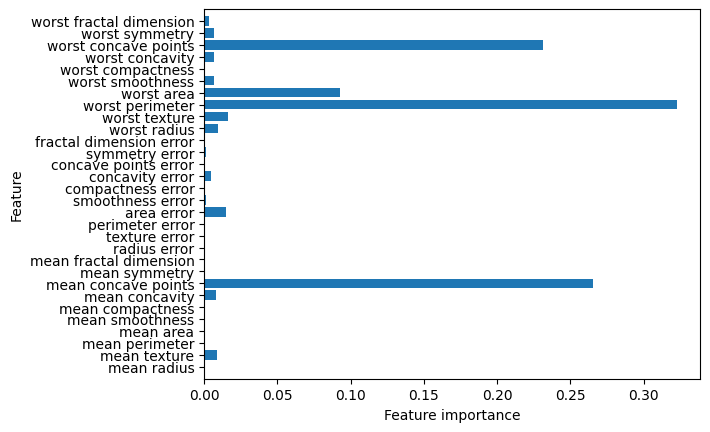

In [9]:
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(np.arange(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_cancer(gbc1)


feature importances of the gradient boosted trees are somewhat similar to the feature importances of the random forests, though the gradient boosting completely ignored some of the features.

As both gradient boosting and random forests perform well on similar kinds of data, a common approach is to first try random forests, which work quite robustly. If random forests work well but prediction time is at a premium, or it is important to squeeze out the last percentage of accuracy from the machine learning model, moving to gradient boosting often helps.